In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split # Added for custom data splitting
import seaborn as sns
from PIL import Image
import os

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: []


In [19]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f'Dataset loaded successfully!')
print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'Image shape      : {X_train.shape[1:]}  (28x28 pixels, grayscale)')
print(f'Label range      : {y_train.min()} to {y_train.max()}')

Dataset loaded successfully!
Training samples : 60000
Testing  samples : 10000
Image shape      : (28, 28)  (28x28 pixels, grayscale)
Label range      : 0 to 9


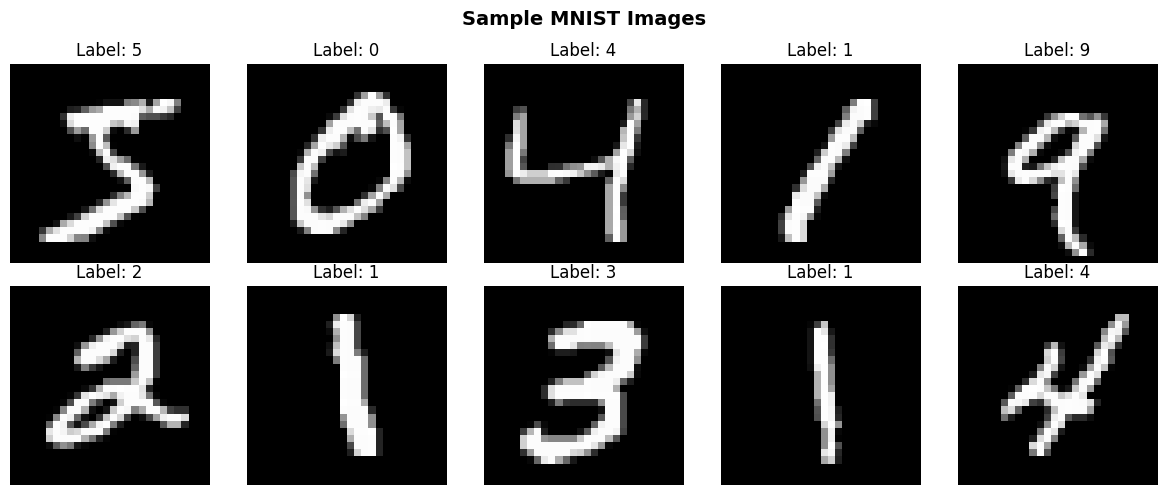

In [20]:

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [21]:

X_combined = np.concatenate((X_train, X_test), axis=0)
y_combined = np.concatenate((y_train, y_test), axis=0)


X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined, test_size=0.1, random_state=42, stratify=y_combined
)

print(f'New training samples : {X_train.shape[0]}')
print(f'New testing  samples : {X_test.shape[0]}')


X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0


X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)


num_classes = 10
y_train_ohe = to_categorical(y_train, num_classes)
y_test_ohe  = to_categorical(y_test,  num_classes)

print('Preprocessing complete!')
print(f'X_train shape : {X_train.shape}  |  dtype: {X_train.dtype}')
print(f'X_test  shape : {X_test.shape}  |  dtype: {X_test.dtype}')
print(f'y_train_ohe   : {y_train_ohe.shape}  (one-hot encoded)')
print(f'Sample label  : {y_train[0]} → {y_train_ohe[0]}')

New training samples : 63000
New testing  samples : 7000
Preprocessing complete!
X_train shape : (63000, 28, 28, 1)  |  dtype: float32
X_test  shape : (7000, 28, 28, 1)  |  dtype: float32
y_train_ohe   : (63000, 10)  (one-hot encoded)
Sample label  : 9 → [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [22]:
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    """
    CNN Architecture:
      Block 1 : Conv(32) → BatchNorm → Conv(32) → BatchNorm → MaxPool → Dropout(0.25)
      Block 2 : Conv(64) → BatchNorm → Conv(64) → BatchNorm → MaxPool → Dropout(0.25)
      Head    : Flatten → Dense(256) → BatchNorm → Dropout(0.5) → Dense(10, softmax)
    """
    model = keras.Sequential([

        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1_1'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2), name='pool1'),
        layers.Dropout(0.25, name='drop1'),


        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_1'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2), name='pool2'),
        layers.Dropout(0.25, name='drop2'),


        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.BatchNormalization(),
        layers.Dropout(0.5, name='drop3'),
        layers.Dense(num_classes, activation='softmax', name='output'),
    ], name='mnist_cnn')

    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [23]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Model compiled successfully!')

Model compiled successfully!


In [24]:

early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)


datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train)

EPOCHS     = 10
BATCH_SIZE = 128

print('Starting training...')
history = model.fit(
    datagen.flow(X_train, y_train_ohe, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test_ohe),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Starting training...
Epoch 1/10
492/492 ━━━━━━━━━━━━━━━━━━━━ 352s 706ms/step - accuracy: 0.9109 - loss: 0.2876 - val_accuracy: 0.8839 - val_loss: 0.3580 - learning_rate: 0.0010
Epoch 2/10
  1/492 ━━━━━━━━━━━━━━━━━━━━ 8:09 998ms/step - accuracy: 0.9609 - loss: 0.1644

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


492/492 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9609 - loss: 0.1644 - val_accuracy: 0.8883 - val_loss: 0.3437 - learning_rate: 0.0010
Epoch 3/10
492/492 ━━━━━━━━━━━━━━━━━━━━ 348s 707ms/step - accuracy: 0.9697 - loss: 0.0972 - val_accuracy: 0.9900 - val_loss: 0.0289 - learning_rate: 0.0010
Epoch 4/10
492/492 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9766 - loss: 0.0710 - val_accuracy: 0.9899 - val_loss: 0.0290 - learning_rate: 0.0010
Epoch 5/10
492/492 ━━━━━━━━━━━━━━━━━━━━ 355s 722ms/step - accuracy: 0.9769 - loss: 0.0742 - val_accuracy: 0.9853 - val_loss: 0.0431 - learning_rate: 0.0010
Epoch 6/10
  1/492 ━━━━━━━━━━━━━━━━━━━━ 4:44 580ms/step - accuracy: 0.9922 - loss: 0.0366
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
492/492 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9922 - loss: 0.0366 - val_accuracy: 0.9854 - val_loss: 0.0436 - learning_rate: 0.0010
Epoch 7/10
492/492 ━━━━━━━━━━━━━━━━━━━━ 365s 708ms/step - accuracy: 0.9833 - loss: 0

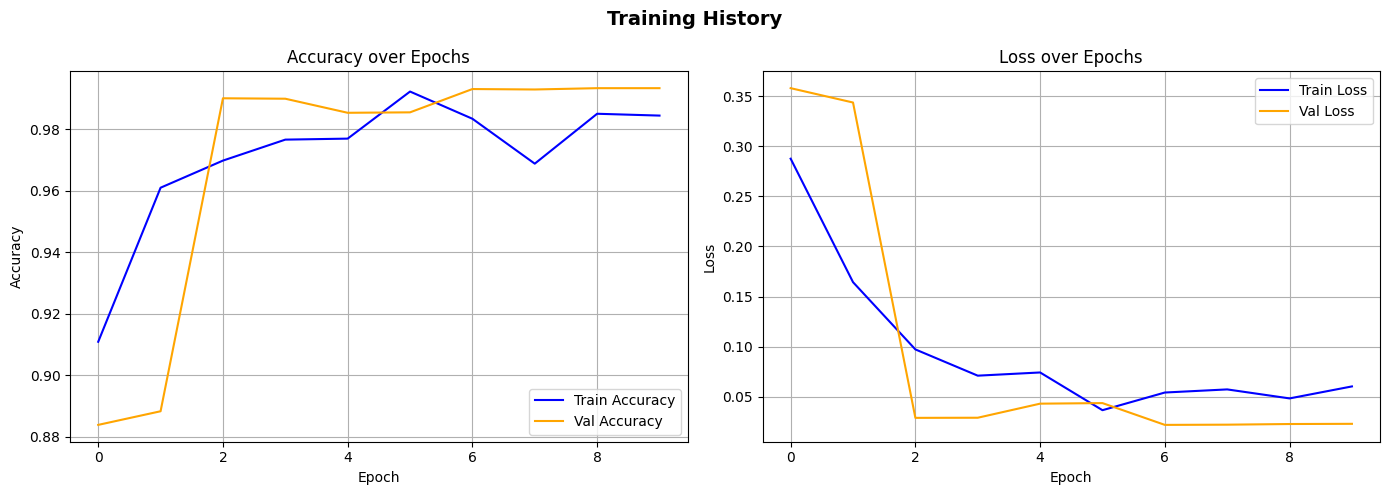

In [25]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

In [26]:

test_loss, test_acc = model.evaluate(X_test, y_test_ohe, verbose=0)
print('=' * 45)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc * 100:.2f}%')
print('=' * 45)

if test_acc >= 0.98:
    print('Target achieved: accuracy ≥ 98%')
else:
    print('Accuracy below 98% — try training for more epochs')

  Test Loss     : 0.0219
  Test Accuracy : 99.30%
Target achieved: accuracy ≥ 98%


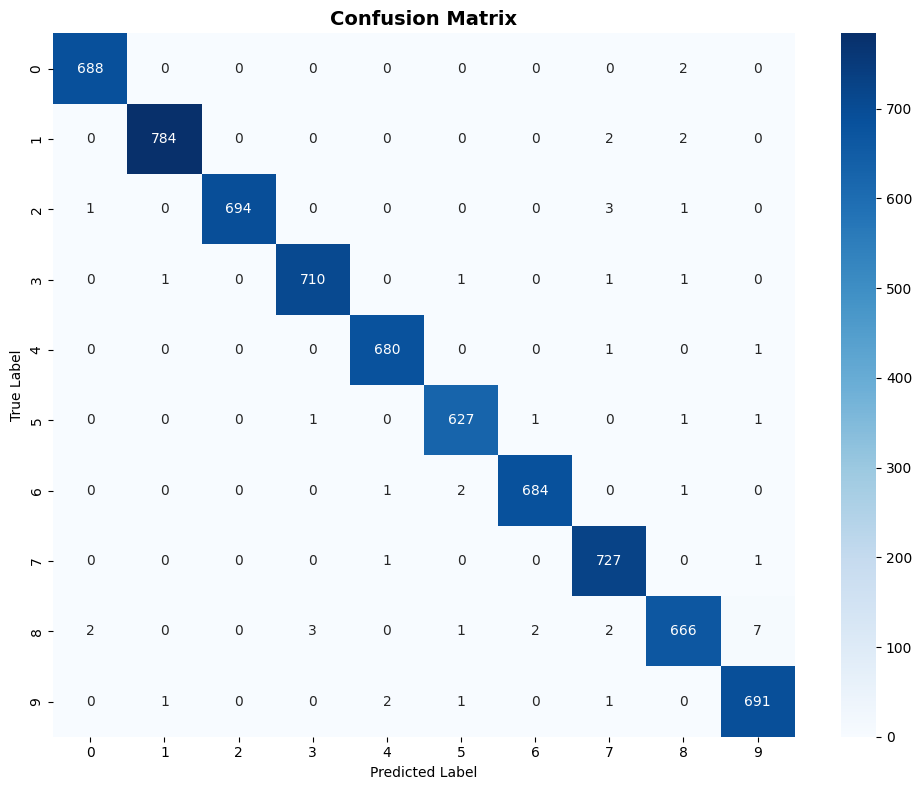

In [27]:

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

In [28]:

print('Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=[str(i) for i in range(10)]))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       690
           1       1.00      0.99      1.00       788
           2       1.00      0.99      1.00       699
           3       0.99      0.99      0.99       714
           4       0.99      1.00      1.00       682
           5       0.99      0.99      0.99       631
           6       1.00      0.99      0.99       688
           7       0.99      1.00      0.99       729
           8       0.99      0.98      0.98       683
           9       0.99      0.99      0.99       696

    accuracy                           0.99      7000
   macro avg       0.99      0.99      0.99      7000
weighted avg       0.99      0.99      0.99      7000



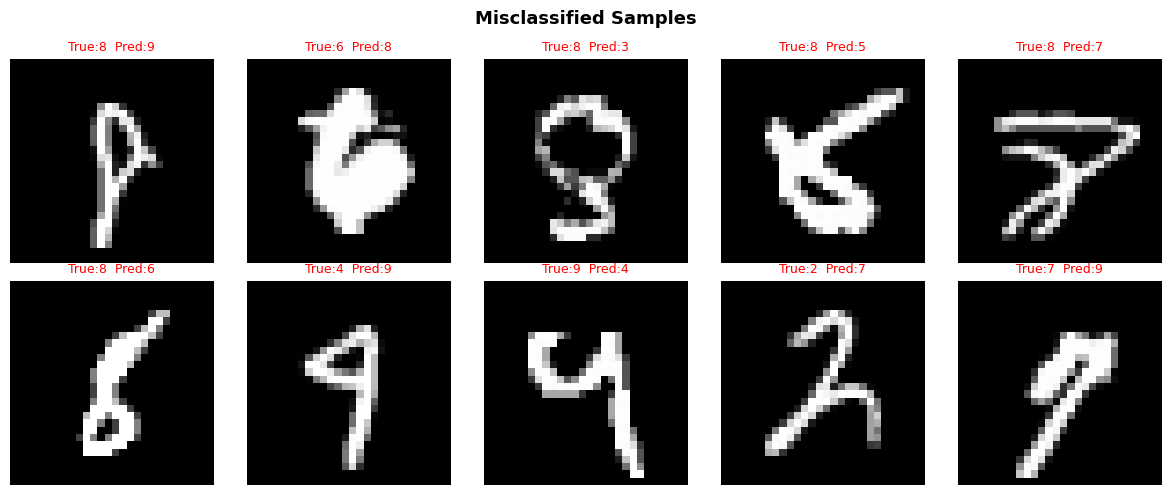

In [29]:

wrong_idx = np.where(y_pred != y_test)[0]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Misclassified Samples', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    idx = wrong_idx[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'True:{y_test[idx]}  Pred:{y_pred[idx]}', color='red', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [30]:

model.save('mnist_cnn_model.keras')
print('Model saved → mnist_cnn_model.keras')

Model saved → mnist_cnn_model.keras


### Test with Custom Images

Found 7 custom image(s): 3.png, 4.png, 6.png, 1.png, 7.png, 2.png, 5.png


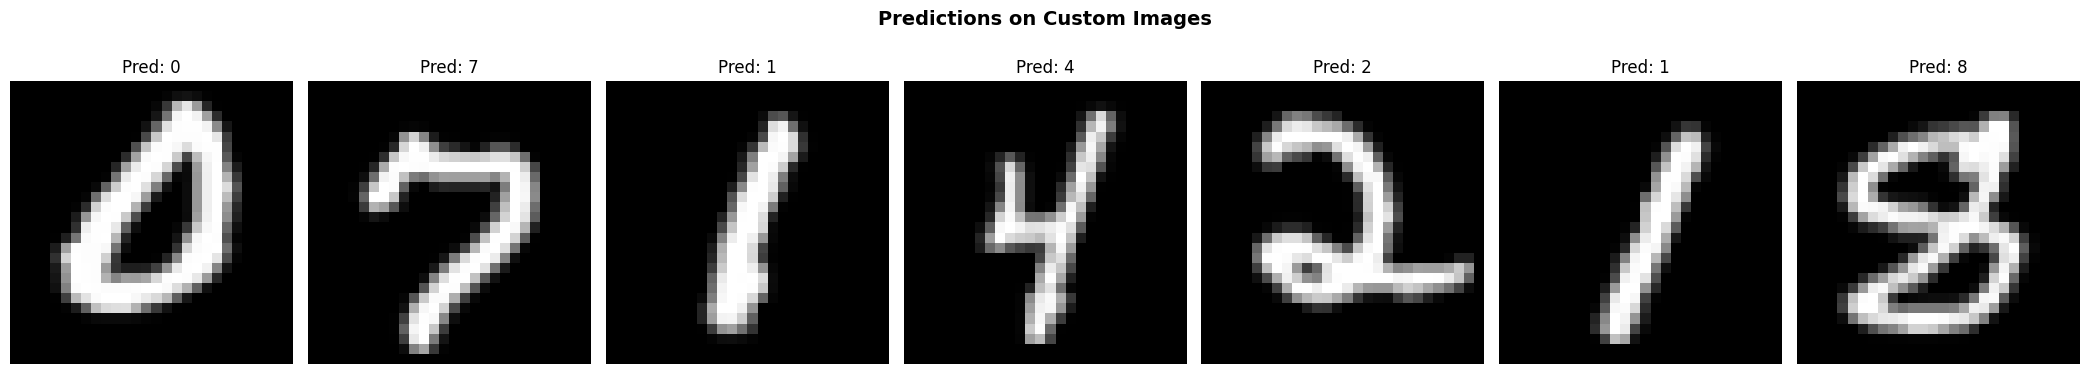

In [31]:

def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')
    img = img.resize((28, 28))
    img_array = np.array(img)
    img_array = img_array.astype('float32') / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)
    return img_array


image_files = [f for f in os.listdir('.') if f.endswith(('.png', '.jpg', '.jpeg'))]

if not image_files:
    print("No custom image files found in the current directory (.png, .jpg, .jpeg).")
else:
    print(f"Found {len(image_files)} custom image(s): {', '.join(image_files)}")

    fig, axes = plt.subplots(1, len(image_files), figsize=(3 * len(image_files), 4))
    if len(image_files) == 1:
        axes = [axes]

    for i, img_file in enumerate(image_files):

        processed_img = preprocess_image(img_file)


        prediction = model.predict(processed_img, verbose=0)
        predicted_label = np.argmax(prediction)


        axes[i].imshow(processed_img.reshape(28, 28), cmap='gray')
        axes[i].set_title(f"Pred: {predicted_label}")
        axes[i].axis('off')

    fig.suptitle('Predictions on Custom Images', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Summary of Work Done

1.  **Environment Setup**: Imported essential libraries like TensorFlow, Keras, Matplotlib, NumPy, and scikit-learn.
2.  **Data Loading and Preprocessing**: Loaded the MNIST dataset. Re-split the data to **90% for training** (63,000 samples) and **10% for testing** (7,000 samples). Images were normalized and reshaped, and labels were one-hot encoded.
3.  **Model Definition**: Defined a Convolutional Neural Network (CNN) with two convolutional blocks, including batch normalization, max pooling, and dropout layers, followed by a fully connected head.
4.  **Model Training**: The model was compiled and trained for 10 epochs, incorporating data augmentation and using `EarlyStopping` and `ReduceLROnPlateau` callbacks.
5.  **Evaluation and Analysis**: After training, the training history curves were plotted. The model was evaluated on the test set, achieving an accuracy of **99.30%**. A confusion matrix, classification report, and visualizations of misclassified samples were generated.
6.  **Model Saving**: The trained model was saved to `mnist_cnn_model.keras`.
7.  **Custom Image Testing**: Processed custom images found in the directory and made predictions using the trained model, displaying each custom image with its predicted digit.